### **[Predicting Stock Price Direction using Support Vector Machines](https://www.geeksforgeeks.org/machine-learning/predicting-stock-price-direction-using-support-vector-machines/)**

> Predicting stock price direction is a key goal for traders and analysts. Support Vector Machines (SVM) is a machine learning algorithm that can help classify whether a stock's price will rise or fall.

In [1]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd

import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

IN_COLAB = 'google.colab' in sys.modules
URL = 'https://media.geeksforgeeks.org/wp-content/uploads/20240918183309/RELIANCE.csv'

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.precision', 4)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

plt.style.use('fivethirtyeight')
#plt.rcParams['']

%autosave 15

Autosaving every 15 seconds


In [2]:
df = pd.read_csv(URL)

df.index = pd.to_datetime(df['Date'])

df = df.drop(['Date'], axis='columns')

display(df.sample(10))

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2013-06-11,391.7500,395.7500,387.6500,392.8000,359.5161,6053872.0000
2013-07-23,456.0250,462.5000,453.6250,454.7750,416.2397,5683014.0000
2011-06-10,477.5500,478.0000,466.0250,472.2500,412.5485,5060272.0000
2011-10-21,420.0000,424.6000,415.5500,417.8750,365.0476,4728350.0000
2010-08-31,472.3250,474.9750,457.5000,459.6000,394.7189,21306256.0000
2013-08-26,411.2500,415.7250,404.2000,411.3000,376.4485,4533278.0000
2013-12-17,424.3500,426.4500,418.3750,419.6000,384.0452,4612544.0000
2012-10-04,425.2750,429.4500,424.5500,426.4500,381.7270,5772464.0000
2009-02-19,322.5000,327.2500,320.5250,323.4380,267.4516,12017532.0000


In [3]:
display(df.describe())

,Open,High,Low,Close,Adj Close,Volume
count,2634.0000,2634.0000,2634.0000,2634.0000,2634.0000,2634.0000
mean,593.5001,600.7875,586.7143,593.4170,556.4358,8622827.5657
std,264.0547,266.5303,261.0985,263.7705,278.3653,5485415.0814
min,0.0000,286.2500,266.2500,269.3880,222.7576,0.0000
25%,432.5687,437.5000,426.9625,432.1250,391.7392,5316242.2500
50%,497.1750,502.5000,491.5500,496.6500,445.4318,7126297.5000
75%,556.1813,565.8750,546.8125,554.6410,524.0525,10093068.5000
max,1407.9500,1417.5000,1402.6500,1408.8500,1401.0911,86244270.0000


In [4]:
# Create predictor variables
df['Open-Close'] = df.Open - df.Close
df['High-Low'] = df.High - df.Low

display(df.head(10))

,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low
Date,,,,,,,,
2009-01-02,314.9250,324.9750,313.0000,321.6000,265.9318,19847448.0000,-6.6750,11.9750
2009-01-05,324.7500,344.2500,323.7750,341.4620,282.3557,22027876.0000,-16.7120,20.4750
2009-01-06,340.0000,347.5000,332.8120,342.7250,283.4001,24118400.0000,-2.7250,14.6880
2009-01-07,342.2500,346.5000,293.7500,300.1880,248.2262,34002200.0000,42.0620,52.7500
2009-01-09,302.5000,302.5000,273.4130,288.3120,238.4058,37952520.0000,14.1880,29.0870
2009-01-12,284.9250,286.2500,271.2500,274.4750,226.9640,29458336.0000,10.4500,15.0000
2009-01-13,273.6750,286.5000,266.2500,269.3880,222.7576,26320964.0000,4.2870,20.2500
2009-01-14,272.7750,304.5000,272.7750,294.9380,243.8849,26201564.0000,-22.1630,31.7250
2009-01-15,285.4500,289.9870,276.8750,285.5870,236.1526,25094924.0000,-0.1370,13.1120


In [5]:
# Store all predictor variables in a variable X
X = df[['Open-Close', 'High-Low']]

# Target variables
y = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

In [6]:
display(X.head())

,Open-Close,High-Low
Date,,
2009-01-02,-6.6750,11.9750
2009-01-05,-16.7120,20.4750
2009-01-06,-2.7250,14.6880
2009-01-07,42.0620,52.7500
2009-01-09,14.1880,29.0870


In [7]:
display(y)

array([1, 1, 0, ..., 1, 0, 0])

In [8]:
split_percentage = 0.8
split = int(split_percentage*len(df))

# Train data set
X_train = X[:split]
y_train = y[:split]

# Test data set
X_test = X[split:]
y_test = y[split:]

print("The data was split into training and testing sets using an 80/20 split.")

The data was split into training and testing sets using an 80/20 split.


In [9]:
# Support vector classifier
clf = SVC()
cls = clf.fit(X_train, y_train)

In [10]:
# Calculate training accuracy
train_accuracy = accuracy_score(y_train, cls.predict(X_train))

# Calculate testing accuracy
test_accuracy = accuracy_score(y_test, cls.predict(X_test))

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 0.5358329378262933
Testing Accuracy: 0.47248576850094876


In [11]:
# Linear kernel
cls_linear = SVC(kernel='linear').fit(X_train, y_train)
y_pred_linear = cls_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy with Linear Kernel: {accuracy_linear}")

Accuracy with Linear Kernel: 0.49146110056925996


In [12]:
# Polynomial kernel
cls_poly = SVC(kernel='poly', degree=3).fit(X_train, y_train)
y_pred_poly = cls_poly.predict(X_test)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy with Polynomial Kernel (degree=3): {accuracy_poly}")

Accuracy with Polynomial Kernel (degree=3): 0.48956356736242884


In [13]:
# RBF kernel (default)
cls_rbf = SVC(kernel='rbf').fit(X_train, y_train)
y_pred_rbf = cls_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy with RBF Kernel: {accuracy_rbf}")

Accuracy with RBF Kernel: 0.47248576850094876


In [14]:
# Sigmoid kernel
cls_sigmoid = SVC(kernel='sigmoid').fit(X_train, y_train)
y_pred_sigmoid = cls_sigmoid.predict(X_test)
accuracy_sigmoid = accuracy_score(y_test, y_pred_sigmoid)
print(f"Accuracy with Sigmoid Kernel: {accuracy_sigmoid}")

Accuracy with Sigmoid Kernel: 0.5047438330170778


In [15]:
df['Predicted_Signal'] = cls.predict(X)

In [16]:
# Calculate daily returns
df['Return'] = df.Close.pct_change()

In [17]:
# Calculate strategy returns
df['Strategy_Return'] = df.Return *df.Predicted_Signal.shift(1)

In [18]:
# Calculate Cumulutive returns
df['Cum_Ret'] = df['Return'].cumsum()

In [19]:
# Plot Strategy Cumulative returns
df['Cum_Strategy'] = df['Strategy_Return'].cumsum()

In [20]:
display(df.head(20))

,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low,Predicted_Signal,Return,Strategy_Return,Cum_Ret,Cum_Strategy
Date,,,,,,,,,,,,,
2009-01-02,314.9250,324.9750,313.0000,321.6000,265.9318,19847448.0000,-6.6750,11.9750,0,NaN,NaN,NaN,NaN
2009-01-05,324.7500,344.2500,323.7750,341.4620,282.3557,22027876.0000,-16.7120,20.4750,1,0.0618,0.0000,0.0618,0.0000
2009-01-06,340.0000,347.5000,332.8120,342.7250,283.4001,24118400.0000,-2.7250,14.6880,0,0.0037,0.0037,0.0655,0.0037
2009-01-07,342.2500,346.5000,293.7500,300.1880,248.2262,34002200.0000,42.0620,52.7500,0,-0.1241,-0.0000,-0.0587,0.0037
2009-01-09,302.5000,302.5000,273.4130,288.3120,238.4058,37952520.0000,14.1880,29.0870,0,-0.0396,-0.0000,-0.0982,0.0037
2009-01-12,284.9250,286.2500,271.2500,274.4750,226.9640,29458336.0000,10.4500,15.0000,0,-0.0480,-0.0000,-0.1462,0.0037
2009-01-13,273.6750,286.5000,266.2500,269.3880,222.7576,26320964.0000,4.2870,20.2500,0,-0.0185,-0.0000,-0.1647,0.0037
2009-01-14,272.7750,304.5000,272.7750,294.9380,243.8849,26201564.0000,-22.1630,31.7250,1,0.0948,0.0000,-0.0699,0.0037
2009-01-15,285.4500,289.9870,276.8750,285.5870,236.1526,25094924.0000,-0.1370,13.1120,0,-0.0317,-0.0317,-0.1016,-0.0280


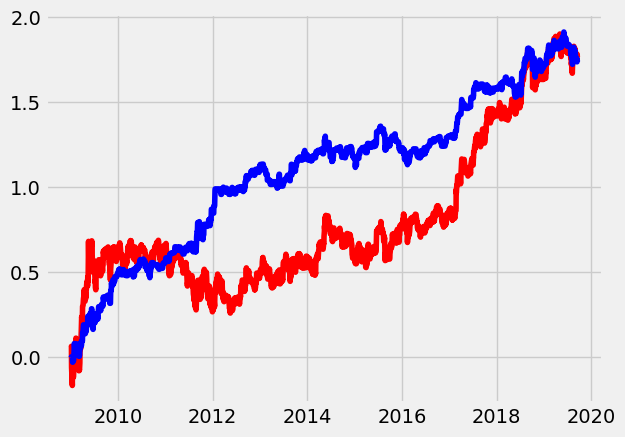

In [21]:
plt.plot(df['Cum_Ret'], color='red')
plt.plot(df['Cum_Strategy'], color='blue')